In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from matplotlib.cm import get_cmap


pd.set_option('display.max_columns', None)

In [66]:
de = pd.read_csv("../../data/ecoli/ecoli_data_2023.tsv", sep="\t")
dp = pd.read_csv("../../data/paeruginosa/paeruginosa_data_2023.tsv", sep="\t")
dk = pd.read_csv("../../data/kpneumoniae/kpneumoniae_data_2023.tsv", sep="\t")

In [67]:
# remove rows with empty patid
de = de[~pd.isna(de.pat_id)]
dk = dk[~pd.isna(dk.pat_id)]
dp = dp[~pd.isna(dp.pat_id)]

In [68]:
def split_dataset_by_SC(dpa: pd.DataFrame) -> dict:
    """
    Splits the input dataset into multiple datasets based on 'SC' values.
    
    Criteria:
    - Groups the data by ['pat_id', 'SC'] and counts occurrences.
    - Filters patients with at least 20 occurrences.
    - Creates separate datasets named as `input_dataframe_name + "_{SC}"` for each unique SC.

    Parameters:
    dpa (pd.DataFrame): Input dataframe containing 'pat_id', 'SC', and 'samplingdate' columns.

    Returns:
    dict: A dictionary where keys are dataset names and values are corresponding filtered DataFrames.
    """
    # Group by 'pat_id' and 'SC', count occurrences, and filter patients with at least 20 occurrences
    valid_patients = (
        dpa.groupby(["pat_id", "SC"])
        .count()
        .query("samplingdate >= 15")
        .reset_index()
    )

    # Merge back to filter only relevant data
    filtered_dpa = dpa.merge(valid_patients[['pat_id', 'SC']], on=['pat_id', 'SC'])

    # Create separate datasets per 'SC' and 'pat_id' combination
    datasets = {
        f"{sc}_{pat_id}": filtered_dpa[(filtered_dpa["SC"] == sc) & (filtered_dpa["pat_id"] == pat_id)]
        for sc, pat_id in filtered_dpa[["SC", "pat_id"]].drop_duplicates().values
    }

    return datasets

In [69]:
datasets_ec = split_dataset_by_SC(de)

for name, df in datasets_ec.items():
    df.to_csv(f"../../data/ecoli/{name}.csv", index=False) 

In [70]:
datasets_pa = split_dataset_by_SC(dp)

for name, df in datasets_pa.items():
    df.to_csv(f"../../data/paeruginosa/{name}.csv", index=False) 

In [71]:
datasets_kp = split_dataset_by_SC(dk)

for name, df in datasets_kp.items():
    df.to_csv(f"../../data/kpneumoniae/{name}.csv", index=False) 

In [116]:
def create_combined_plot_from_datasets(datasets, date_col='samplingdate', pat_col='pat_id', SC_col='SC', 
                                       species="", custom_palette=None, save_path=None):
    """
    Creates a combined scatterplot from multiple datasets.

    Parameters:
        datasets (dict): Dictionary where keys are dataset names and values are DataFrames.
        date_col (str): Column name for sampling dates.
        pat_col (str): Column name for patient IDs.
        SC_col (str): Column name for SC values.
        species (str): Species name to include in the title.
        custom_palette (dict): Dictionary mapping SC values to colors.
        save_path (str or None): Path where the plot should be saved. If None, the plot is not saved.

    Returns:
        None. Displays the combined scatterplot and saves it if `save_path` is provided.
    """
    if not datasets:
        raise ValueError("No datasets provided.")

    combined_data = pd.concat(datasets.values(), ignore_index=True)

    if combined_data.empty:
        raise ValueError("The combined dataset is empty after concatenation.")

    # Convert to datetime and sort data
    combined_data[date_col] = pd.to_datetime(combined_data[date_col], errors='coerce')
    combined_data = combined_data.sort_values(by=[date_col, SC_col, pat_col])

    # Ensure SC values are strings for mapping
    combined_data[SC_col] = combined_data[SC_col].astype(str)
    # Filter out the unwanted SC value for E. coli
    if species == "escherichia_coli":
        combined_data = combined_data[combined_data[SC_col] != "5_472_800_1025_1036_1065_1265"]


    # Ensure custom_palette keys are strings
    if custom_palette:
        SC_color_map = {str(k): v for k, v in custom_palette.items()}
    else:
        SC_color_map = None

    # Check for missing SC values in the color mapping
    unique_SCs = combined_data[SC_col].dropna().unique()
    missing_SCs = set(unique_SCs) - set(SC_color_map.keys()) if SC_color_map else set()

    if missing_SCs:
        raise ValueError(f"Custom palette is missing colors for SC values: {missing_SCs}")

    # Plot settings
    sns.set_style("white")
    plt.figure(figsize=(15, 4.5), dpi=150)

    scatter_plot = sns.scatterplot(
        x=date_col, y=pat_col, data=combined_data, hue=SC_col, 
        palette=SC_color_map, legend="full" if len(unique_SCs) > 1 else False, 
        alpha=0.6, s=100, edgecolor="black"
    )

    # Adjust legend if applicable
    if len(unique_SCs) > 1:
        handles, labels = scatter_plot.get_legend_handles_labels()
        sorted_labels_handles = sorted(zip(labels, handles), key=lambda x: x[0])
        labels, handles = zip(*sorted_labels_handles)
        scatter_plot.legend(handles, labels, bbox_to_anchor=(1.05, 0.5), loc='center left', title=SC_col)

    # X-ticks formatting
    scatter_plot.xaxis.set_major_locator(MaxNLocator(12))
    plt.xticks(rotation=35)

    # Adjust layout and save plot
    plt.title(f"{species}")
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    if save_path:
        plt.savefig(f"{save_path}/combined_plot_patients_SC_{species}.svg", format="svg", dpi=300, transparent=True)
        plt.savefig(f"{save_path}/combined_plot_patients_SC_{species}.png", format="png", dpi=300, transparent=True)

    plt.show()

In [73]:
color_mapping_pa = {
    135: "#ae7181",
    286: "#9a0eea",
    13: "#bf77f6",
    4: "#35063e",
    28: "#cb416b",
    125: "#a85597",
    138: "#87257c",
    18: "#c98acb",
    2: "#5f2167",
    25: "#d896ff",
    298: "#7b41c0",
    3: "#632b63",
    33: "#e9a3e3",
    44: "#9400d3",
    76: "#b57edc"
}

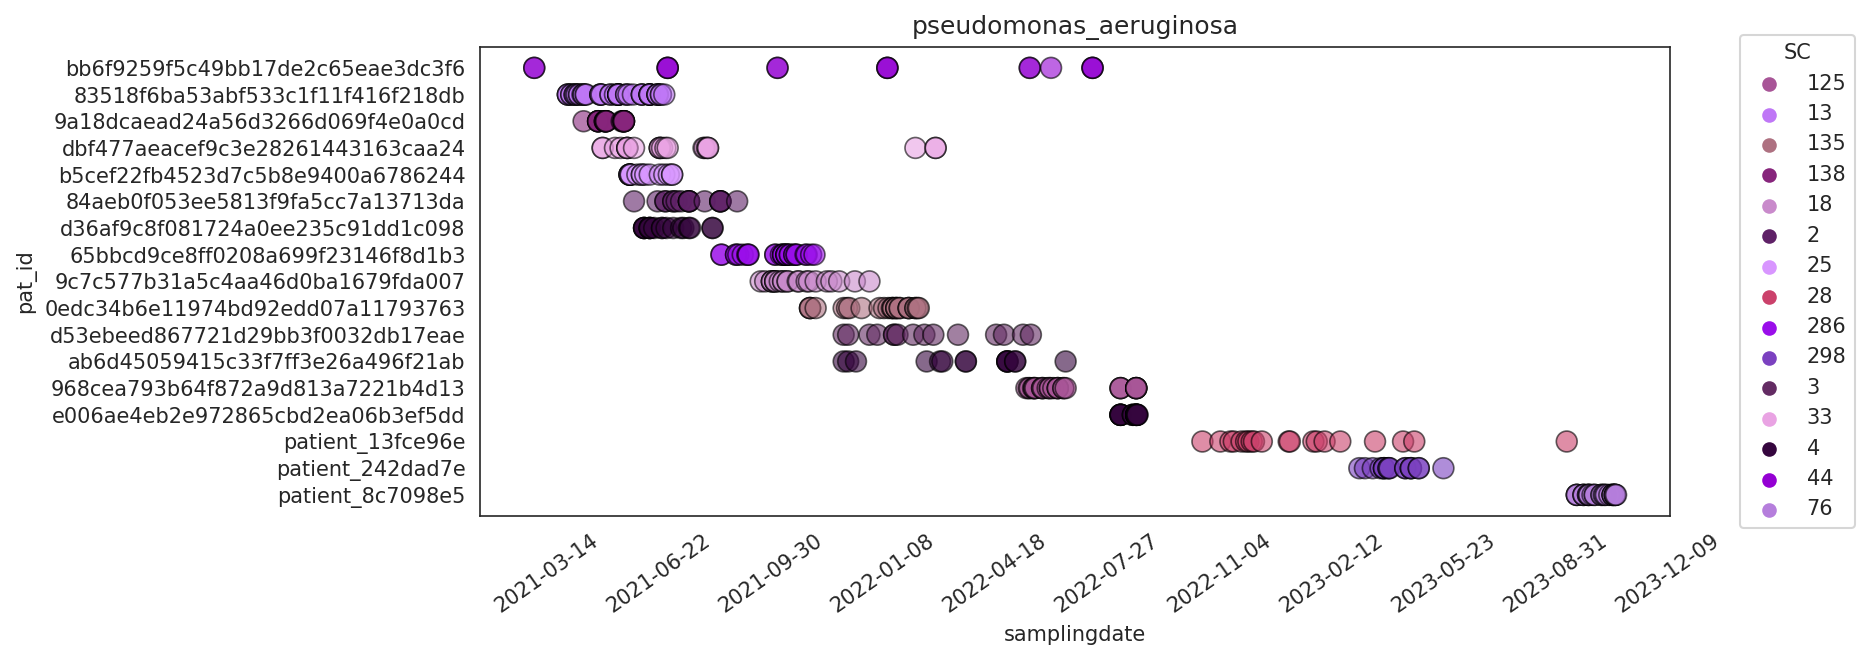

In [117]:
create_combined_plot_from_datasets(datasets_pa, species="pseudomonas_aeruginosa", 
                                   custom_palette=color_mapping_pa, save_path="../../out/figures");

In [80]:
color_mapping_ec = {
    11: "#0343df",
    25: "#75bbfd", 
    94: "#0504aa", 
    73: "#d0fefe",
    67: "#00035b",
    15: "#2a4d69", 
    29: "#7da7d9", 
    4: "#35063e",
    "70_572": "#028f76", 
    8: "#1c1cf0",
    9: "#0033cc",
}

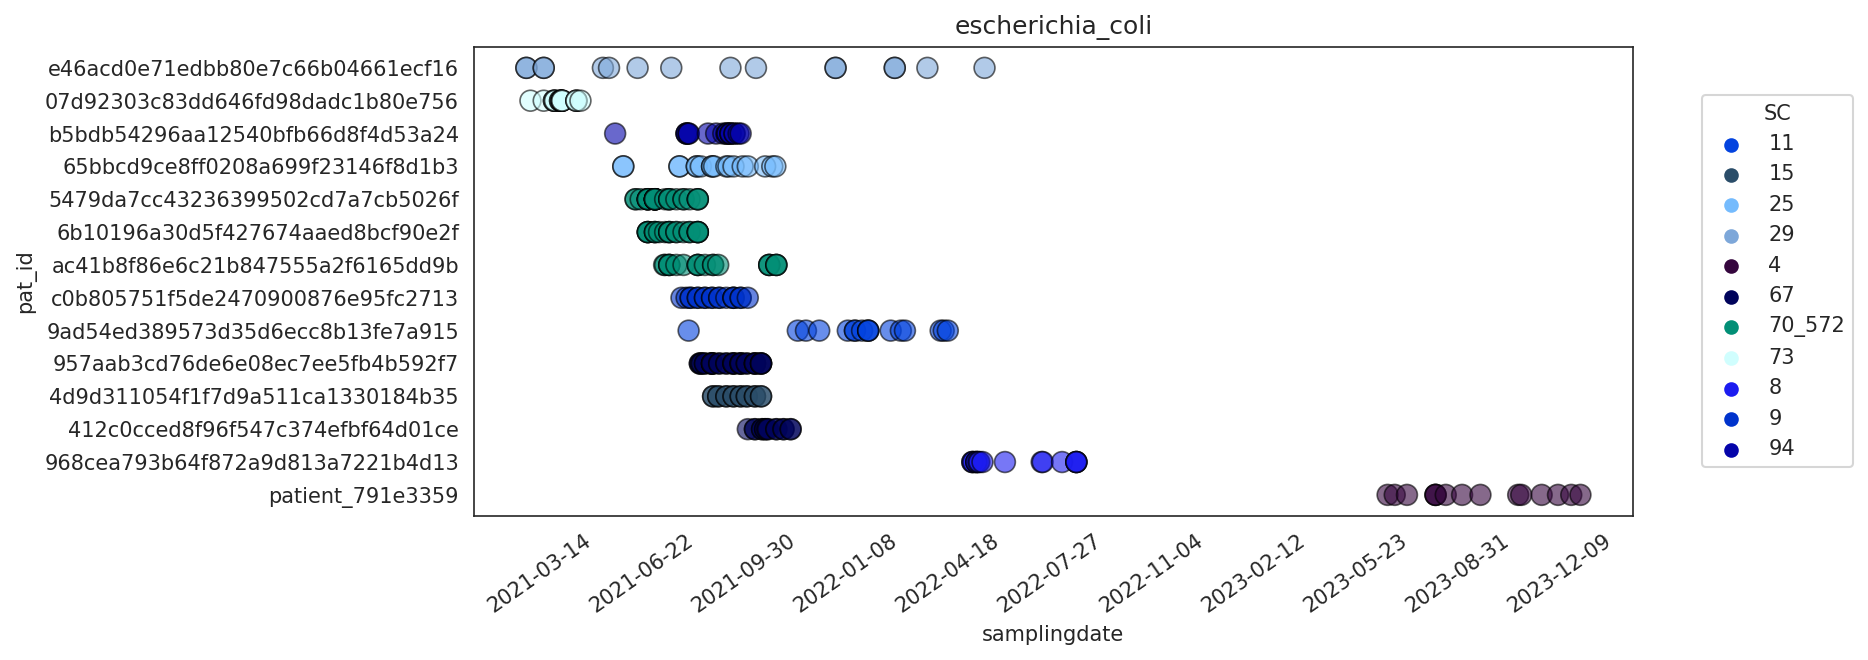

In [118]:
create_combined_plot_from_datasets(datasets_ec, species="escherichia_coli", 
                                   custom_palette=color_mapping_ec, save_path="../../out/figures");

In [82]:
color_mapping_kp = {
    34: "#f97306",
    297: "#8f1402",
    303: "#cb416b",
    19: "#cb416b",
    1: "#e50000",
    15: "#a52a2a",
    "2_195": "#800000",
    3: "#c04e01",
    301: "#b22222", 
    302: "#ff4500",
    8: "#ff6347", 
    88: "#cc4e5c",
    9: "#ff2400",
    97: "#c32148" 
}

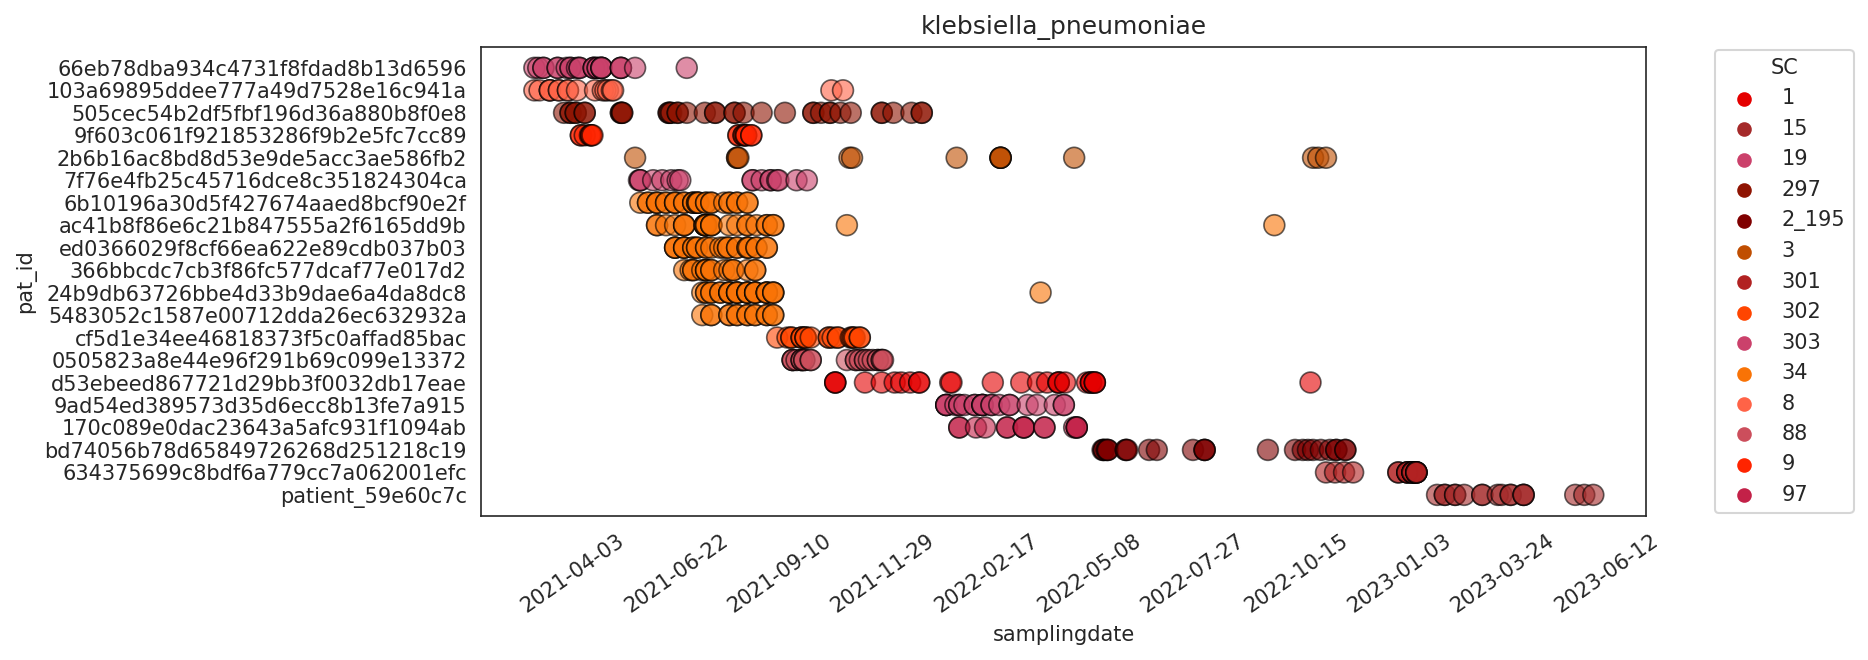

In [119]:
create_combined_plot_from_datasets(datasets_kp, species="klebsiella_pneumoniae", 
                                   custom_palette=color_mapping_kp, save_path="../../out/figures");